In [1]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.9 MB/s eta 0:00:00


In [2]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re


In [3]:
os.environ["GROQ_API_KEY"]="YOUR_GROQ_API_KEY"


In [4]:
client=Groq(api_key=os.environ["GROQ_API_KEY"])

In [5]:
MODEL="llama-3.1-8b-instant"

In [6]:
print(MODEL)

llama-3.1-8b-instant


In [8]:
import io
df=pd.read_csv('student_performance.csv')
print(df)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

In [9]:
conn=sqlite3.connect('college.db')
df.to_sql('students',conn,if_exists='replace',index=False)

30

In [14]:
def get_schema(conn, table_name):
    cursor = conn.cursor()
    schema_lines = []

    # Get schema information
    cursor.execute(f"PRAGMA table_info({table_name})")
    schema = cursor.fetchall()
    schema_lines.append(f"Table: {table_name}")
    schema_lines.append("Columns:")
    for col in schema:
        schema_lines.append(f"- {col[1]} ({col[2]})")

    # Get sample rows
    cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
    sample_rows = cursor.fetchall()
    if sample_rows:
        schema_lines.append("\nSample rows (first 3):")
        for row in sample_rows:
            row_str = ', '.join(map(str, row))
            schema_lines.append(f"  {row_str}")
    else:
        schema_lines.append("\nNo sample rows available.")

    return "\n".join(schema_lines)

In [16]:
schema=get_schema(conn, 'students')
print(schema)

Table: students
Columns:
- student_id (INTEGER)
- name (TEXT)
- age (INTEGER)
- gender (TEXT)
- department (TEXT)
- semester (INTEGER)
- math_score (INTEGER)
- science_score (INTEGER)
- english_score (INTEGER)
- programming_score (INTEGER)
- attendance_percentage (INTEGER)
- city (TEXT)
- admission_year (INTEGER)

Sample rows (first 3):
  1001, Aarav Sharma, 19, Male, Computer Science, 2, 85, 78, 72, 91, 92, Mumbai, 2023
  1002, Priya Patel, 20, Female, Computer Science, 2, 76, 82, 88, 79, 87, Ahmedabad, 2023
  1003, Rohit Verma, 19, Male, Electronics, 2, 65, 74, 61, 55, 78, Delhi, 2023


In [17]:
system_prompt = """
You are an expert SQL assistant.
use this structure:{schema_text}
Your task is to generate only SQLite SQL queries
based on the user question and database schema.

Rules:
1. Return only SQL query
2. Do not add explanations
3. Use only available columns from schema
4. Generate valid SQLite syntax
5. Do not include markdown
"""

In [34]:
def generate_sql(user_question,schema_text,client,model):
  """
  this is the description function for generating sql queries

  """

  system_prompt = f"""
  You are an expert SQL assistant.

  Your task is to generate only SQLite SQL queries
  based on the user question and database schema.

  {schema_text}

  Rules:
  1. Return only SQL query
  2. Do not add explanations
  3. Use only available columns from schema
  4. Generate valid SQLite syntax
  5. Do not include markdown
  6. IMPORTANT: For the 'gender' column, values are 'Male' or 'Female'. Ensure your query uses these exact values for filtering.
  """

  response  = client.chat.completions.create(
    model = model,
    messages = [
      {"role": "system","content": system_prompt},
      {"role": "user","content": user_question}
    ],
    temperature = 0.0
  )

  sql_query = response.choices[0].message.content.strip()
  return sql_query

In [25]:
question="Show me all Male students"
sql_query=generate_sql(question,schema,client,MODEL)
print(sql_query)

SELECT * FROM students WHERE gender = 'Male'


In [31]:
# This was an old definition of execute_sql. It is being removed to avoid conflicts.

In [32]:
def execute_sql(sql_query,conn):
    """
    Clean and execute SQL query on SQLite database.

    Parameters:
    sql_query : str
        SQL query generated by LLM

    conn : sqlite3.Connection
        SQLite database connection object

    Returns:
    result_df : pandas.DataFrame
        Query execution result
    """

    clean_sql = sql_query.strip()
    clean_sql = re.sub(r'```\S*', '', clean_sql)
    clean_sql = clean_sql.strip()

    try:
        result_df = pd.read_sql_query(clean_sql, conn)
        return result_df, None
    except Exception as e:
        return None, str(e)

In [26]:
print(f"Executing SQL:{sql_query}")
result_df,error=execute_sql(sql_query)
if error:
  print(error)
else:
  print(result_df)

Executing SQL:SELECT * FROM students WHERE gender = 'Male'
    student_id            name  age gender        department  semester  \
0         1001    Aarav Sharma   19   Male  Computer Science         2   
1         1003     Rohit Verma   19   Male       Electronics         2   
2         1005      Arjun Nair   19   Male  Computer Science         2   
3         1007     Kiran Kumar   21   Male             Civil         2   
4         1009    Rahul Mishra   20   Male        Mechanical         2   
5         1011     Vikram Iyer   20   Male       Electronics         2   
6         1013      Suresh Rao   21   Male  Computer Science         2   
7         1015     Ajay Tiwari   19   Male  Computer Science         2   
8         1017    Manoj Pandey   21   Male             Civil         2   
9         1019  Deepak Chauhan   20   Male        Mechanical         2   
10        1021   Harish Pillai   20   Male       Electronics         2   
11        1023    Sanjay Dubey   21   Male           

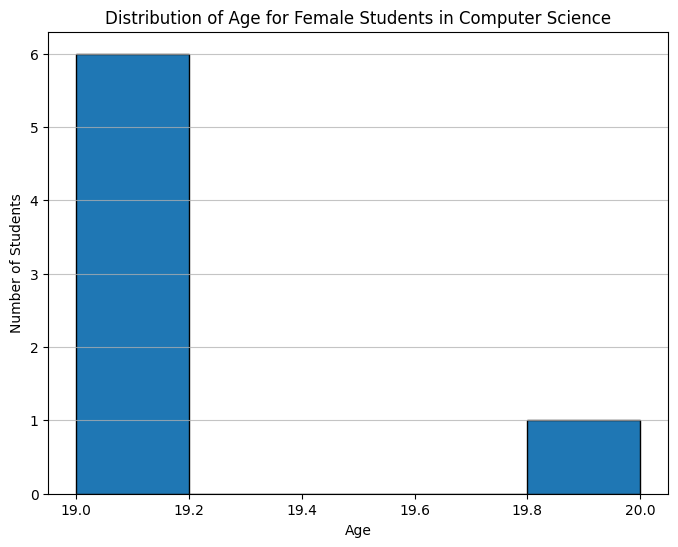

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(result_from_agent['age'], bins=5, edgecolor='black')
plt.title('Distribution of Age for Female Students in Computer Science')
plt.xlabel('Age')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [37]:
def text_to_sql_agent(user_question, schema, client, MODEL, conn):
    """
    Orchestrates the generation and execution of SQL queries from natural language with verbose logging.

    Parameters:
    user_question (str): The natural language question from the user.
    schema (str): The database schema to inform SQL generation.
    client: The Groq API client.
    MODEL (str): The LLM model to use for SQL generation.
    conn: The SQLite database connection object.

    Returns:
    pandas.DataFrame or None: The result of the SQL query as a DataFrame, or None if an error occurs.
    """
    print(f"--- Agent Starting ---")
    print(f"[Step 1] Received User Question: '{user_question}'")

    print(f"[Step 2] Generating SQL query using model: {MODEL}...")
    sql_query = generate_sql(user_question, schema, client, MODEL)
    print(f"[Step 3] LLM Generated SQL: {sql_query}")

    print(f"[Step 4] Executing SQL query on the database...")
    result_df, error = execute_sql(sql_query, conn)

    if error:
        print(f"[Error] SQL execution failed with message: {error}")
        return None
    else:
        print(f"[Step 5] SQL query executed successfully. Found {len(result_df)} records.")
        print(f"--- Agent Task Complete ---")
        return result_df

In [38]:
user_question = "Show me all female students from Computer Science department."
result_from_agent = text_to_sql_agent(user_question, schema, client, MODEL, conn)

if result_from_agent is not None:
    print(f"\nFinal Output Table:")
    display(result_from_agent)
else:
    print(f"Failed to retrieve data for '{user_question}'.")

--- Agent Starting ---
[Step 1] Received User Question: 'Show me all female students from Computer Science department.'
[Step 2] Generating SQL query using model: llama-3.1-8b-instant...
[Step 3] LLM Generated SQL: SELECT * FROM students WHERE gender = 'Female' AND department = 'Computer Science';
[Step 4] Executing SQL query on the database...
[Step 5] SQL query executed successfully. Found 7 records.
--- Agent Task Complete ---

Final Output Table:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
1,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
2,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023
3,1018,Swati Kulkarni,19,Female,Computer Science,2,90,87,85,92,94,Nagpur,2023
4,1020,Nisha Kapoor,19,Female,Computer Science,2,79,84,81,83,89,Chandigarh,2023
5,1022,Tanvi Mehta,19,Female,Computer Science,2,93,90,88,96,97,Surat,2023
6,1030,Akanksha Yadav,19,Female,Computer Science,2,91,93,87,94,95,Agra,2023


In [40]:
#the complete text to sql agent function
def text_to_sql_agent(user_question,conn,client,model,verbose = True):
  """
    Complete AI Text-to-SQL Agent

    Workflow:
    1. Read database schema
    2. Generate SQL query using Groq LLM
    3. Execute SQL query
    4. Return results

    Parameters:
    user_question : str
        Natural language user query

    conn : sqlite3.Connection
        SQLite database connection

    client : Groq
        Groq API client

    model : str
        Groq model name

    verbose : bool
        Print intermediate outputs

    Returns:
    result_df : pandas.DataFrame
        Final query results
    """

  print("User Question:", user_question)

  if verbose:
    print("[Step 1] Reading Databse schema ...")
  schema_text = get_schema(conn, 'students')

  if verbose:
    print("Schema loaded successfully")
    print()

  if verbose:
    print("[Step 2]Generating SQL query with GROQ LLM........")

  generated_sql = generate_sql(user_question,schema_text,client,model)

  if verbose:
    print("Generated SQL:", generated_sql)
    print()
  if verbose:
    print("[Step 3] Executing SQL on the database.....")

  result_df,error = execute_sql(generated_sql,conn)

  if error:
    print("SQL Error:", error)
    return None, generated_sql
  else:
    print("Query Returned:", len(result_df))
    print()
    print("RESULTS:")
    print(result_df.to_string(index=False))


  return result_df, generated_sql

result,sql_used = text_to_sql_agent(question, conn, client, MODEL)

User Question: Show me all Male students
[Step 1] Reading Databse schema ...
Schema loaded successfully

[Step 2]Generating SQL query with GROQ LLM........
Generated SQL: SELECT * FROM students WHERE gender = 'Male'

[Step 3] Executing SQL on the database.....
Query Returned: 15

RESULTS:
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023
       1003    Rohit Verma   19   Male      Electronics         2          65             74             61                 55                     78              Delhi            2023
       1005     Arjun Nair   19   Male Computer Science         2          92             88             81                 95                     90      